# 🚗 Smart parking system

In [2]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 7.5 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO
import ultralytics
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Ultralytics version:", ultralytics.__version__)
print("YOLO imported successfully!")

Ultralytics version: 8.4.121
YOLO imported successfully!


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key= ROBOFLOW_API_KEY)
project = rf.workspace("laila-badawy").project("parking-detection-jeremykevin-7ad3t")
version = project.version(2)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 123.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to parking-detection-jeremyKevin-2 in yolov8:: 100%|██████████| 5931/5931 [00:03<00:00, 1527.39it/s]


In [1]:
from google.colab import userdata

ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY")

print("API key loaded successfully!")

API key loaded successfully!


In [3]:
import os

dataset_path = "/content/parking-detection-jeremyKevin-2"

print("Dataset path:", dataset_path)
print("\nDataset contents:")
print(os.listdir(dataset_path))

Dataset path: /content/parking-detection-jeremyKevin-2

Dataset contents:
['README.roboflow.txt', 'train', 'valid', 'data.yaml', 'README.dataset.txt', 'test']


In [4]:
import yaml

yaml_path = os.path.join(dataset_path, "data.yaml")

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print("Dataset YAML:")
print(data)

Dataset YAML:
{'names': ['car', 'free'], 'nc': 2, 'roboflow': {'license': 'CC BY 4.0', 'project': 'parking-detection-jeremykevin-7ad3t', 'url': 'https://universe.roboflow.com/laila-badawy/parking-detection-jeremykevin-7ad3t/dataset/2', 'version': 2, 'workspace': 'laila-badawy'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}


In [5]:
from pathlib import Path

for split in ["train", "valid", "test"]:
    images_path = Path(dataset_path) / split / "images"
    labels_path = Path(dataset_path) / split / "labels"

    images_count = len(list(images_path.glob("*")))
    labels_count = len(list(labels_path.glob("*.txt")))

    print(f"{split.upper()}:")
    print(f"  Images: {images_count}")
    print(f"  Labels: {labels_count}")

TRAIN:
  Images: 1301
  Labels: 1301
VALID:
  Images: 1110
  Labels: 1110
TEST:
  Images: 552
  Labels: 552


In [6]:
from collections import Counter

class_counts = Counter()

for split in ["train", "valid", "test"]:
    labels_path = Path(dataset_path) / split / "labels"

    for label_file in labels_path.glob("*.txt"):
        with open(label_file, "r") as f:
            for line in f:
                line = line.strip()
                if line:
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1

print("Annotation counts:")

for class_id, count in sorted(class_counts.items()):
    print(f"Class {class_id} ({data['names'][class_id]}): {count}")

Annotation counts:
Class 0 (car): 64979
Class 1 (free): 57262


In [9]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 6.3 MB/s eta 0:00:00


In [10]:
from ultralytics.data.utils import check_det_dataset

dataset_info = check_det_dataset(yaml_path)

print("Dataset check completed successfully!")
print("Classes:", dataset_info["names"])

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset check completed successfully!
Classes: {0: 'car', 1: 'free'}


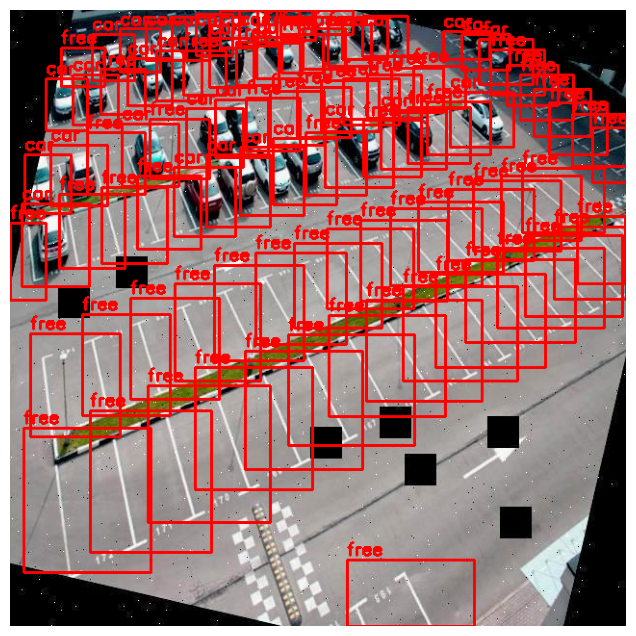

In [11]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

image_path = next((Path(dataset_path) / "train" / "images").glob("*"))
label_path = Path(dataset_path) / "train" / "labels" / (image_path.stem + ".txt")

image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w = image.shape[:2]

with open(label_path, "r") as f:
    for line in f:
        values = line.strip().split()

        class_id = int(values[0])
        x_center, y_center, box_w, box_h = map(float, values[1:5])

        x1 = int((x_center - box_w / 2) * w)
        y1 = int((y_center - box_h / 2) * h)
        x2 = int((x_center + box_w / 2) * w)
        y2 = int((y_center + box_h / 2) * h)

        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

        label = data["names"][class_id]

        cv2.putText(
            image,
            label,
            (x1, max(y1 - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [13]:
from pathlib import Path
import shutil

# Original dataset
src = Path("/content/parking-detection-jeremyKevin-2")

# Clean dataset
dst = Path("/content/parking-detection-clean")

# Create clean dataset structure
for split in ["train", "valid", "test"]:
    (dst / split / "images").mkdir(parents=True, exist_ok=True)
    (dst / split / "labels").mkdir(parents=True, exist_ok=True)

# Copy images and clean labels
converted = 0
detection_rows = 0
segmentation_rows = 0

for split in ["train", "valid", "test"]:
    src_images = src / split / "images"
    src_labels = src / split / "labels"

    # Copy images
    for image_file in src_images.iterdir():
        if image_file.is_file():
            shutil.copy2(image_file, dst / split / "images" / image_file.name)

    # Convert labels
    for label_file in src_labels.glob("*.txt"):
        output_label = dst / split / "labels" / label_file.name

        new_lines = []

        with open(label_file, "r") as f:
            for line in f:
                values = line.strip().split()

                if not values:
                    continue

                class_id = values[0]
                coords = list(map(float, values[1:]))

                # Normal YOLO Detection:
                # class + x_center + y_center + width + height
                if len(coords) == 4:
                    new_lines.append(
                        f"{class_id} "
                        f"{coords[0]:.6f} "
                        f"{coords[1]:.6f} "
                        f"{coords[2]:.6f} "
                        f"{coords[3]:.6f}\n"
                    )
                    detection_rows += 1

                # YOLO Segmentation:
                # class + polygon x,y coordinates
                elif len(coords) >= 6 and len(coords) % 2 == 0:
                    xs = coords[0::2]
                    ys = coords[1::2]

                    x_min = min(xs)
                    x_max = max(xs)
                    y_min = min(ys)
                    y_max = max(ys)

                    x_center = (x_min + x_max) / 2
                    y_center = (y_min + y_max) / 2
                    width = x_max - x_min
                    height = y_max - y_min

                    new_lines.append(
                        f"{class_id} "
                        f"{x_center:.6f} "
                        f"{y_center:.6f} "
                        f"{width:.6f} "
                        f"{height:.6f}\n"
                    )

                    segmentation_rows += 1
                    converted += 1

        with open(output_label, "w") as f:
            f.writelines(new_lines)

# Copy data.yaml and update paths
import yaml

with open(src / "data.yaml", "r") as f:
    data_clean = yaml.safe_load(f)

data_clean["path"] = str(dst)
data_clean["train"] = "train/images"
data_clean["val"] = "valid/images"
data_clean["test"] = "test/images"

with open(dst / "data.yaml", "w") as f:
    yaml.safe_dump(data_clean, f, sort_keys=False)

print("✅ Clean dataset created successfully!")
print("📁 Location:", dst)
print("🔄 Segmentation rows converted:", converted)
print("📦 Detection rows kept:", detection_rows)
print("📊 Total segmentation rows:", segmentation_rows)
print("Classes:", data_clean["names"])

✅ Clean dataset created successfully!
📁 Location: /content/parking-detection-clean
🔄 Segmentation rows converted: 9146
📦 Detection rows kept: 113095
📊 Total segmentation rows: 9146
Classes: ['car', 'free']


In [14]:
from ultralytics.data.utils import check_det_dataset

clean_yaml = "/content/parking-detection-clean/data.yaml"

clean_info = check_det_dataset(clean_yaml)

print("✅ Clean dataset check passed!")
print("Classes:", clean_info["names"])

✅ Clean dataset check passed!
Classes: {0: 'car', 1: 'free'}


##YOLO Model Training

In [15]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/parking-detection-clean/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    patience=10,
    project="/content/smart_parking",
    name="vehicle_detection_clean"
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/parking-detection-clean/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle_detection_

In [16]:
from ultralytics import YOLO

model = YOLO("/content/smart_parking/vehicle_detection_clean/weights/best.pt")

In [32]:
from google.colab import files

uploaded = files.upload()

Saving p2.jpg to p2 (1).jpg



image 1/1 /content/p2 (1).jpg: 896x1280 75 cars, 125 frees, 35.6ms
Speed: 5.6ms preprocess, 35.6ms inference, 1.9ms postprocess per image at shape (1, 3, 896, 1280)


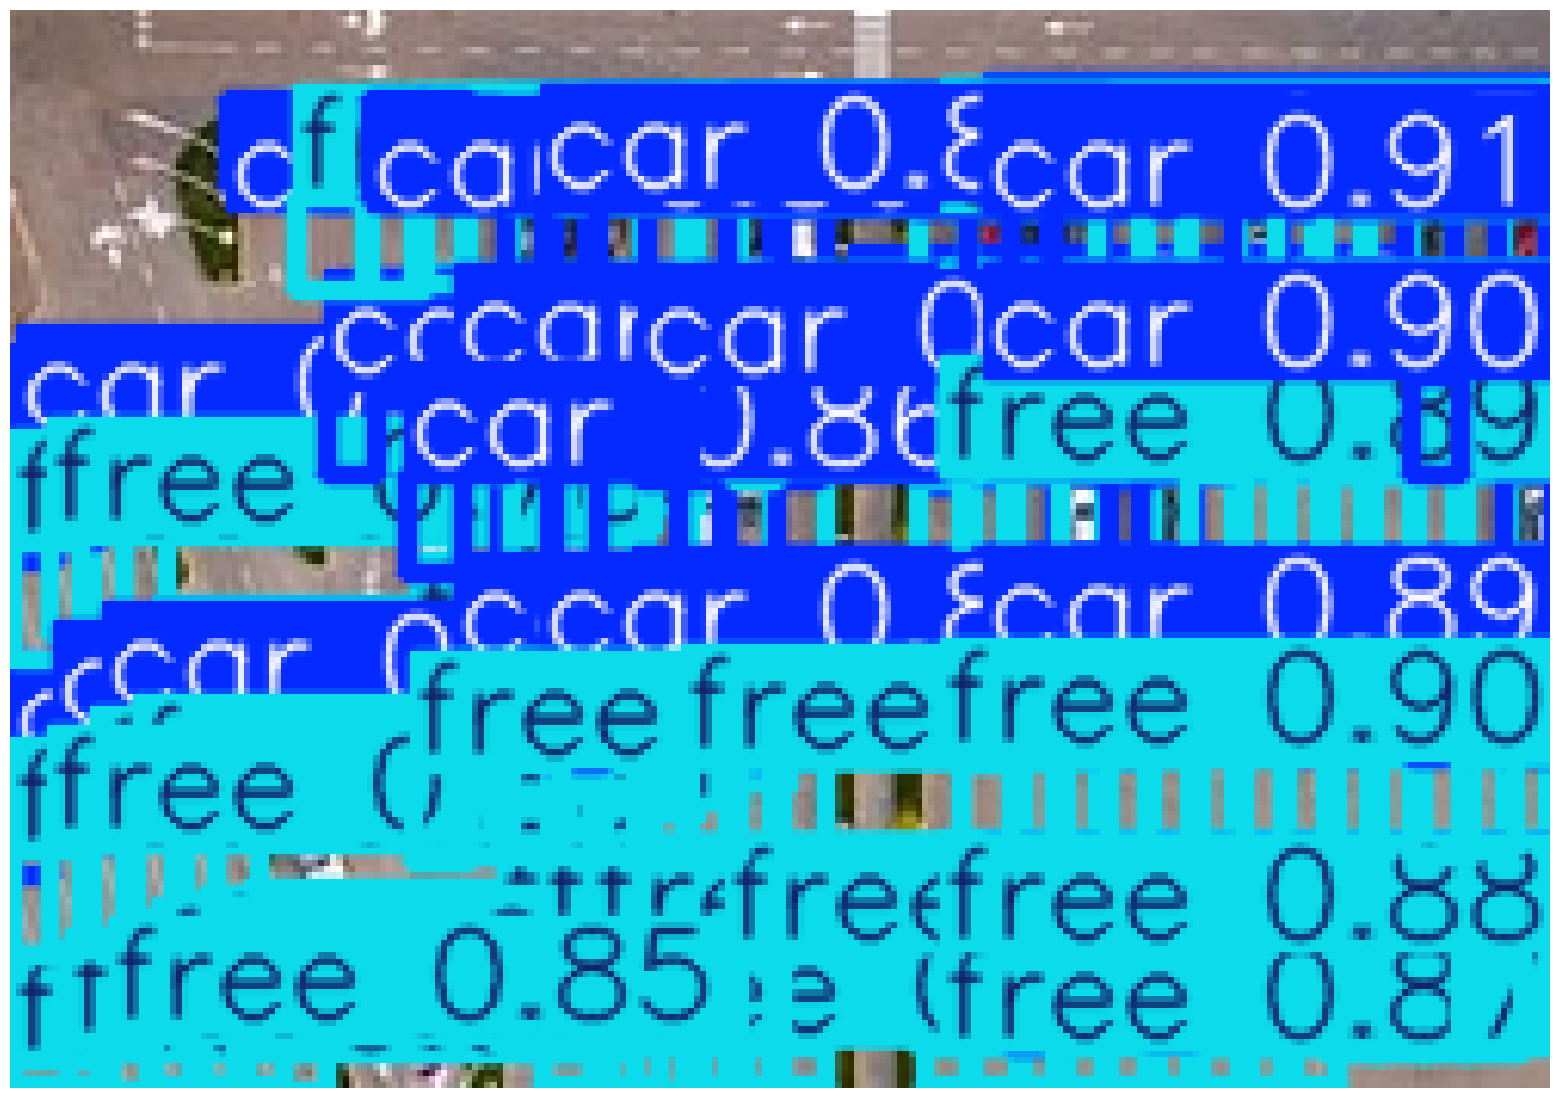

Occupied (cars): 75
Available (free): 125
Total spots: 200
Occupancy rate: 37.5%


In [36]:
import matplotlib.pyplot as plt
from collections import Counter

results = model.predict(
    source="/content/p2 (1).jpg",
    conf=0.4,
    iou=0.4,
    imgsz=1280,
    save=False
)

annotated = results[0].plot(line_width=2, font_size=10)
plt.figure(figsize=(20, 14))
plt.imshow(annotated[..., ::-1])
plt.axis("off")
plt.show()

names = results[0].names
classes = results[0].boxes.cls.tolist()
counts = Counter([names[int(c)] for c in classes])

occupied = counts.get("car", 0)
available = counts.get("free", 0)
total = occupied + available
rate = round(occupied / total * 100, 1) if total else 0

print(f"Occupied (cars): {occupied}")
print(f"Available (free): {available}")
print(f"Total spots: {total}")
print(f"Occupancy rate: {rate}%")


===== results.png =====


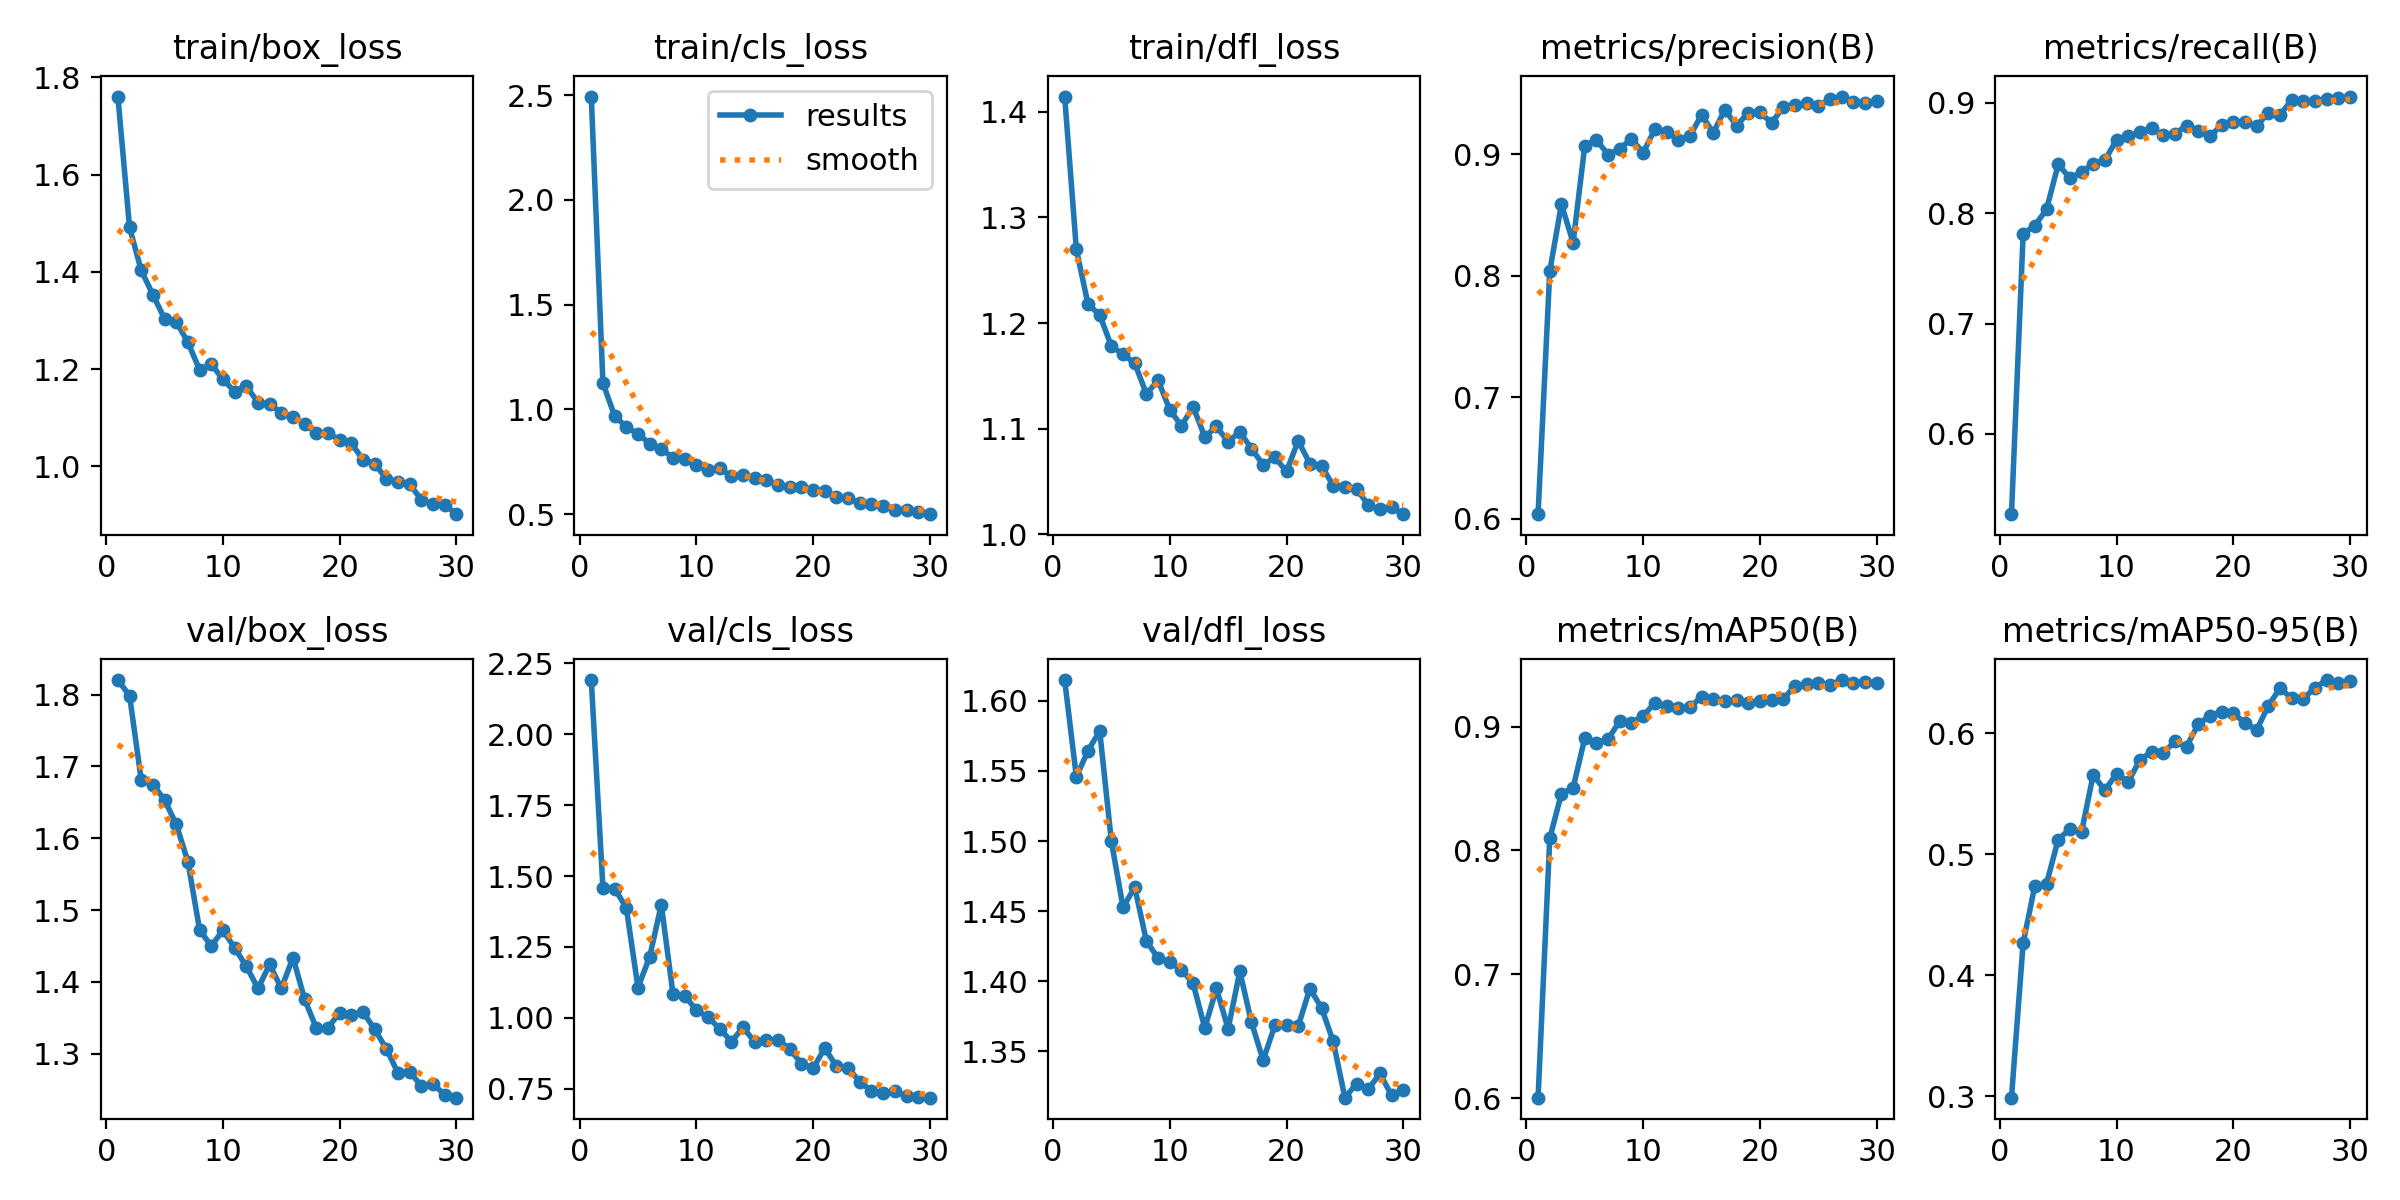


===== confusion_matrix.png =====


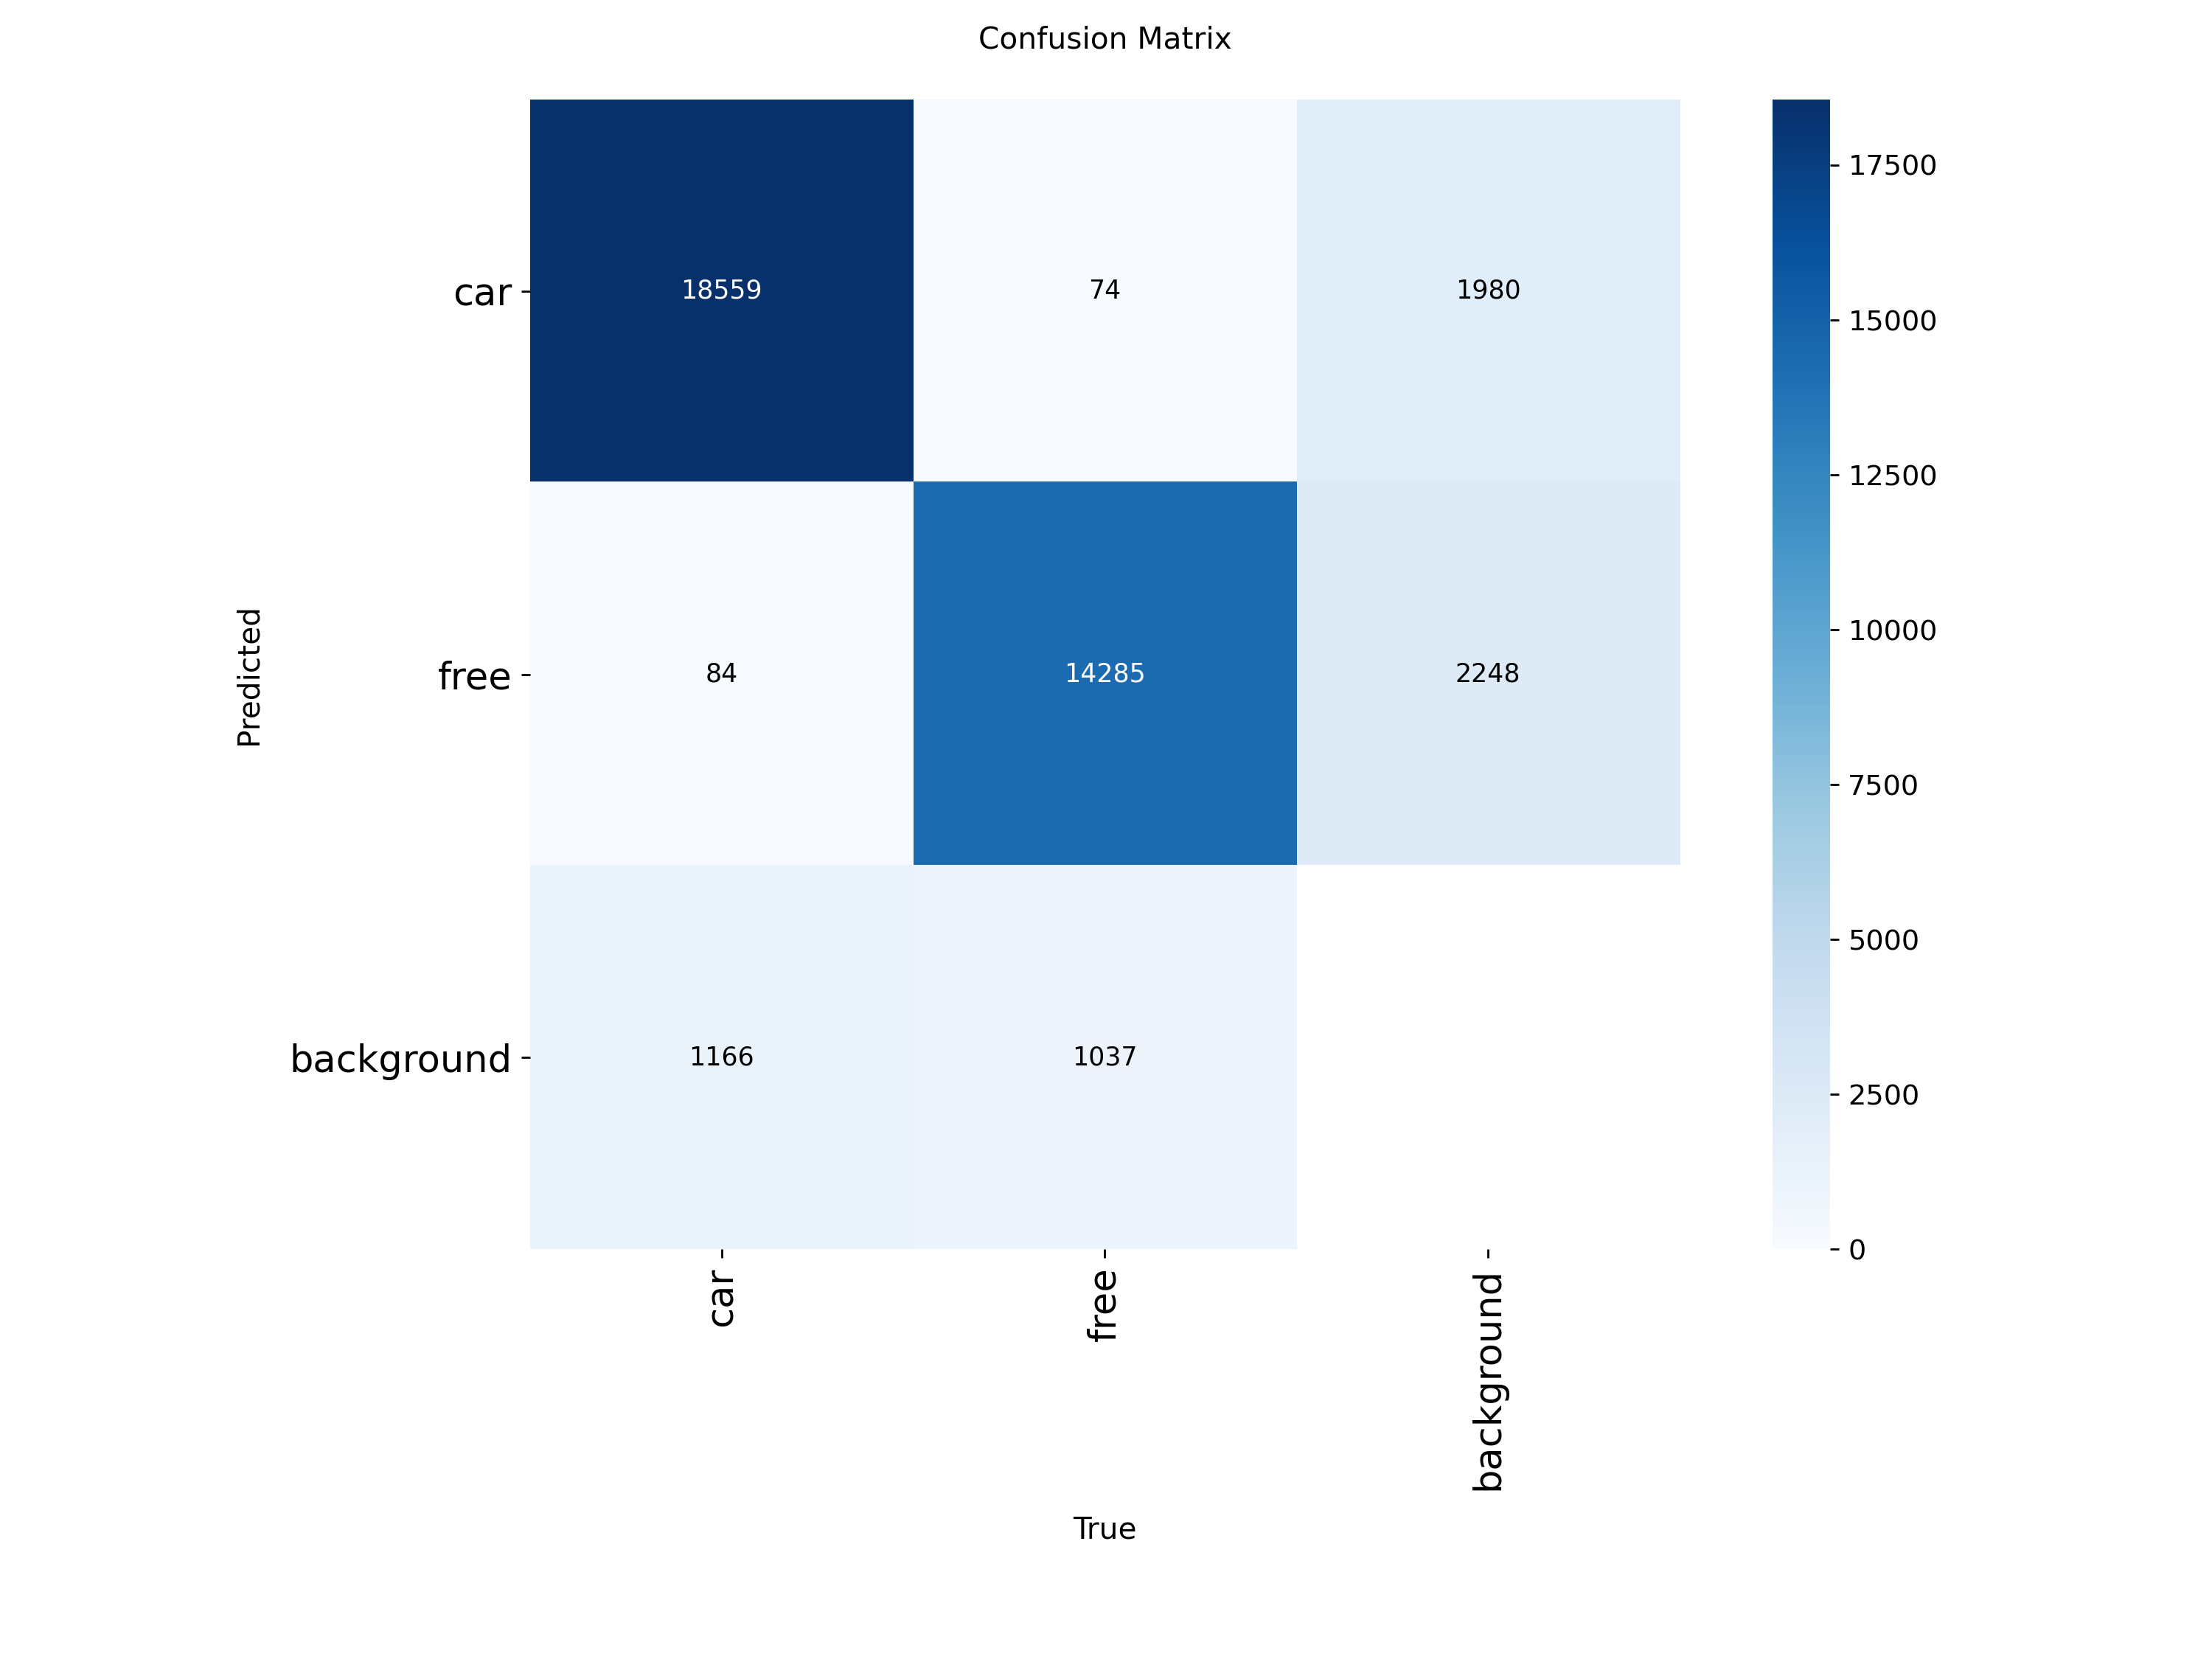

Not found: PR_curve.png
Not found: F1_curve.png
Not found: P_curve.png
Not found: R_curve.png


In [38]:
from IPython.display import display
from PIL import Image
import os

results_dir = "/content/smart_parking/vehicle_detection_clean"

files = [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png"
]

for file in files:
    path = os.path.join(results_dir, file)

    if os.path.exists(path):
        print(f"\n===== {file} =====")
        display(Image.open(path))
    else:
        print(f"Not found: {file}")

In [39]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/smart_parking/vehicle_detection_clean/weights/best.pt"
)

metrics = best_model.val(
    data="/content/parking-detection-clean/data.yaml",
    imgsz=640,
    device=0
)

print("Precision:", round(metrics.box.mp, 4))
print("Recall:", round(metrics.box.mr, 4))
print("mAP50:", round(metrics.box.map50, 4))
print("mAP50-95:", round(metrics.box.map, 4))

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1978.7±408.3 MB/s, size: 76.6 KB)
val: Scanning /content/parking-detection-clean/valid/labels.cache... 1110 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1110/1110 310.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 70/70 2.9it/s 24.3s
                   all       1110      35205      0.943      0.904      0.935      0.644
                   car        986      19809      0.947      0.911      0.937      0.601
                  free       1046      15396       0.94      0.897      0.933      0.688
Speed: 1.4ms preprocess, 3.9ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/val
Precision: 0.9431
Recall: 0.9039
mAP50: 0.9352
mAP50-95: 0.6445


##ROI

In [63]:
print("Image width:", img_rgb.shape[1])
print("Image height:", img_rgb.shape[0])

Image width: 250
Image height: 175


Image size: 250 x 175


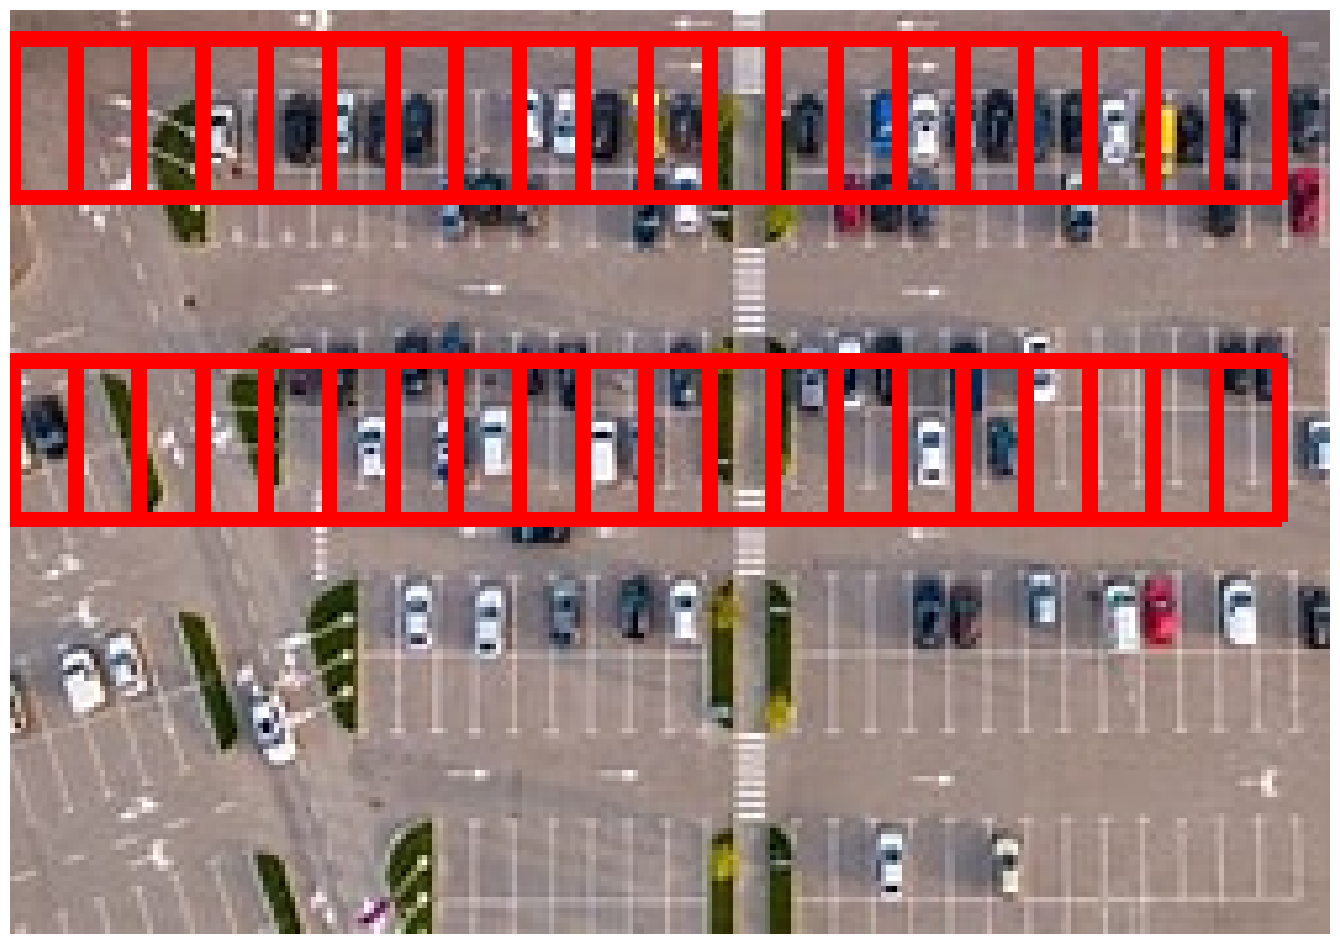

In [64]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import json

img = cv2.imread("/content/p2.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img_rgb.shape[:2]
print(f"Image size: {w} x {h}")

# ====== Settings to adjust if not accurate ======
num_spots_row1 = 20   # number of spots in the top row
num_spots_row2 = 20   # number of spots in the bottom row

# height ratios for each row (0 to 1) - adjust based on the image
row1_top    = 0.03
row1_bottom = 0.20

row2_top    = 0.38
row2_bottom = 0.55
# ===================================================

def make_row(y_top_ratio, y_bottom_ratio, num_spots, w, h):
    row_top = int(h * y_top_ratio)
    row_bottom = int(h * y_bottom_ratio)
    spot_width = w // num_spots
    row_spots = []
    for i in range(num_spots):
        x1 = i * spot_width
        x2 = x1 + spot_width
        row_spots.append([(x1, row_top), (x2, row_top), (x2, row_bottom), (x1, row_bottom)])
    return row_spots

spots = []
spots += make_row(row1_top, row1_bottom, num_spots_row1, w, h)
spots += make_row(row2_top, row2_bottom, num_spots_row2, w, h)

# draw for review
img_check = img_rgb.copy()
for spot in spots:
    pts = np.array(spot, np.int32)
    cv2.polylines(img_check, [pts], True, (255, 0, 0), 2)

plt.figure(figsize=(18, 12))
plt.imshow(img_check)
plt.axis("off")
plt.show()

Image size: 250 x 175


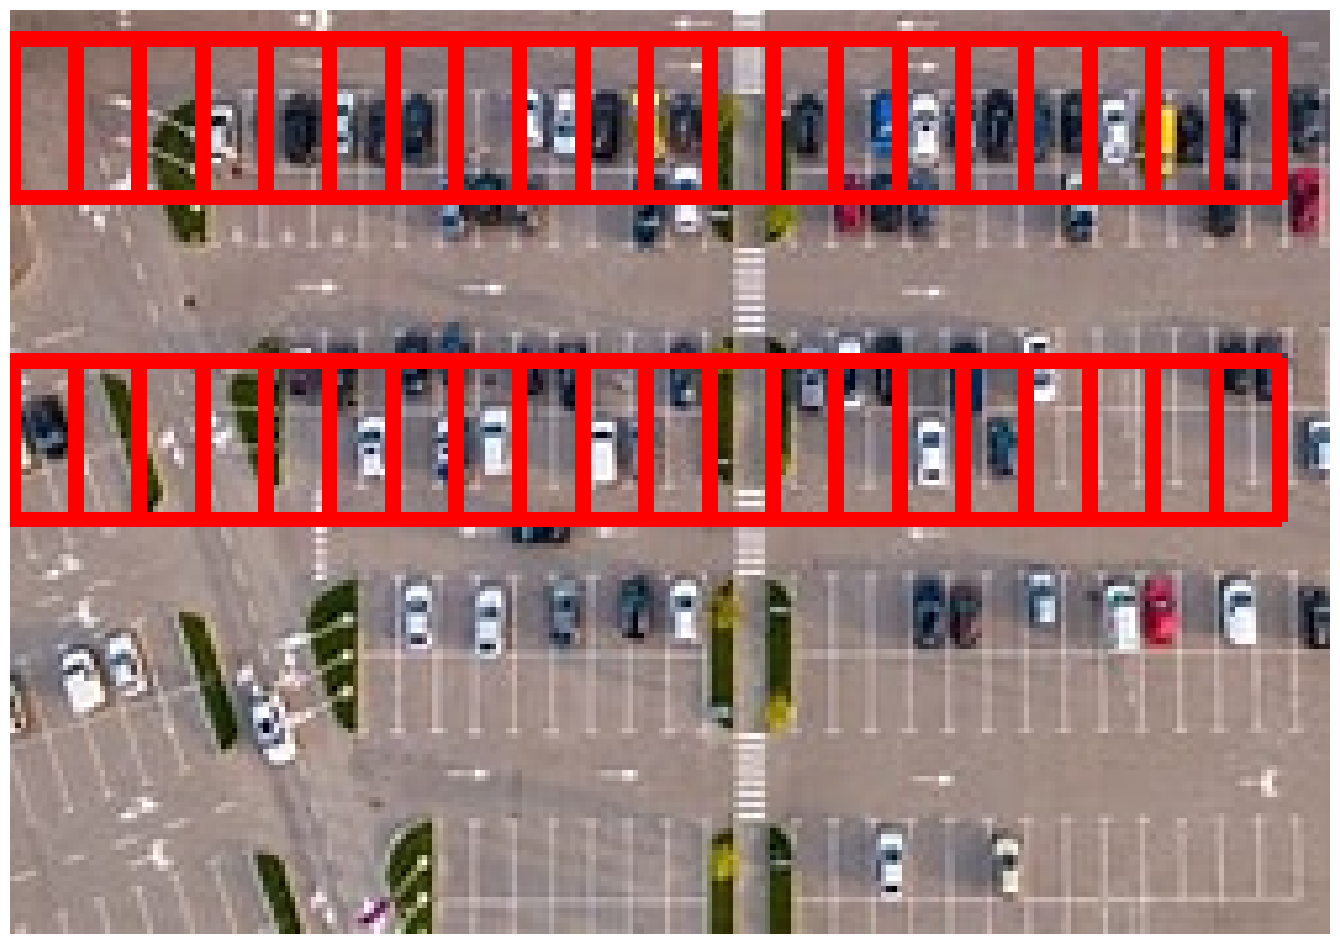

Saved: 40 spots


In [65]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import json

img = cv2.imread("/content/p2.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img_rgb.shape[:2]
print(f"Image size: {w} x {h}")

num_spots_row1 = 20
num_spots_row2 = 20

row1_top    = 0.03
row1_bottom = 0.20

row2_top    = 0.38
row2_bottom = 0.55

def make_row(y_top_ratio, y_bottom_ratio, num_spots, w, h):
    row_top = int(h * y_top_ratio)
    row_bottom = int(h * y_bottom_ratio)
    spot_width = w // num_spots
    row_spots = []
    for i in range(num_spots):
        x1 = i * spot_width
        x2 = x1 + spot_width
        row_spots.append([(x1, row_top), (x2, row_top), (x2, row_bottom), (x1, row_bottom)])
    return row_spots

spots = []
spots += make_row(row1_top, row1_bottom, num_spots_row1, w, h)
spots += make_row(row2_top, row2_bottom, num_spots_row2, w, h)

img_check = img_rgb.copy()
for spot in spots:
    pts = np.array(spot, np.int32)
    cv2.polylines(img_check, [pts], True, (255, 0, 0), 2)

plt.figure(figsize=(18, 12))
plt.imshow(img_check)
plt.axis("off")
plt.show()

# Save immediately in the same cell
json.dump(spots, open("/content/parking_spots.json", "w"))
print("Saved:", len(spots), "spots")

In [62]:
from ultralytics import YOLO
import cv2
import numpy as np
import json

model = YOLO("/content/smart_parking/vehicle_detection_clean/weights/best.pt")
spots = json.load(open("/content/parking_spots.json"))

def check_occupancy(image_path):
    results = model.predict(source=image_path, conf=0.4, iou=0.4, imgsz=1280, verbose=False)
    car_boxes = []
    names = results[0].names
    for box in results[0].boxes:
        cls_name = names[int(box.cls[0])]
        if cls_name == "car":
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            car_boxes.append((x1, y1, x2, y2))

    status = []
    for spot in spots:
        poly = np.array(spot, np.int32)
        occupied = False
        for (x1, y1, x2, y2) in car_boxes:
            cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
            if cv2.pointPolygonTest(poly, (cx, cy), False) >= 0:
                occupied = True
                break
        status.append("occupied" if occupied else "available")
    return status

status = check_occupancy("/content/p2.jpg")

num_row1 = 20

occupied_spots = []
available_spots = []

for i, s in enumerate(status):
    if i < num_row1:
        label = f"Row 1 - Spot {i+1}"
    else:
        label = f"Row 2 - Spot {i-num_row1+1}"
    if s == "occupied":
        occupied_spots.append(label)
    else:
        available_spots.append(label)

print("🔴 Occupied spots:")
for s in occupied_spots:
    print(" -", s)

print("\n🟢 Available spots:")
for s in available_spots:
    print(" -", s)

print(f"\nTotal: {len(status)} | Occupied: {len(occupied_spots)} | Available: {len(available_spots)}")
print(f"Occupancy rate: {round(len(occupied_spots)/len(status)*100, 1)}%")

🔴 Occupied spots:
 - Row 1 - Spot 4
 - Row 1 - Spot 5
 - Row 1 - Spot 6
 - Row 1 - Spot 7
 - Row 1 - Spot 9
 - Row 1 - Spot 10
 - Row 1 - Spot 11
 - Row 1 - Spot 13
 - Row 1 - Spot 14
 - Row 1 - Spot 15
 - Row 1 - Spot 16
 - Row 1 - Spot 17
 - Row 1 - Spot 18
 - Row 1 - Spot 19
 - Row 1 - Spot 20
 - Row 2 - Spot 1
 - Row 2 - Spot 5
 - Row 2 - Spot 6
 - Row 2 - Spot 7
 - Row 2 - Spot 8
 - Row 2 - Spot 9
 - Row 2 - Spot 10
 - Row 2 - Spot 11
 - Row 2 - Spot 13
 - Row 2 - Spot 14
 - Row 2 - Spot 15
 - Row 2 - Spot 16
 - Row 2 - Spot 17
 - Row 2 - Spot 20

🟢 Available spots:
 - Row 1 - Spot 1
 - Row 1 - Spot 2
 - Row 1 - Spot 3
 - Row 1 - Spot 8
 - Row 1 - Spot 12
 - Row 2 - Spot 2
 - Row 2 - Spot 3
 - Row 2 - Spot 4
 - Row 2 - Spot 12
 - Row 2 - Spot 18
 - Row 2 - Spot 19

Total: 40 | Occupied: 29 | Available: 11
Occupancy rate: 72.5%
